# Palettes Preview

This notebook previews every palette, shows color‑vision deficiency simulations, and demonstrates discrete/continuous scales on plots and maps.

Palettes are organized by category at the repository root (e.g., `bioluminescence/`, `impressionist/`, `cities/`).

In [1]:
required <- c("ggplot2", "colorspace", "maps")
for (pkg in required) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg)
  }
}

library(ggplot2)
library(colorspace)

In [6]:
source("R/palettes-data.R")
source("R/palettes.R")

palette_names <- list_palettes()
palette_names

[1] "lillies"       "palazzo"       "wheatfield"    "miami"        
 [5] "santa_barbara" "e_berryi"      "e_scolopes"    "gpo"          
 [9] "ostracod"      "rosysunset"

## All palettes

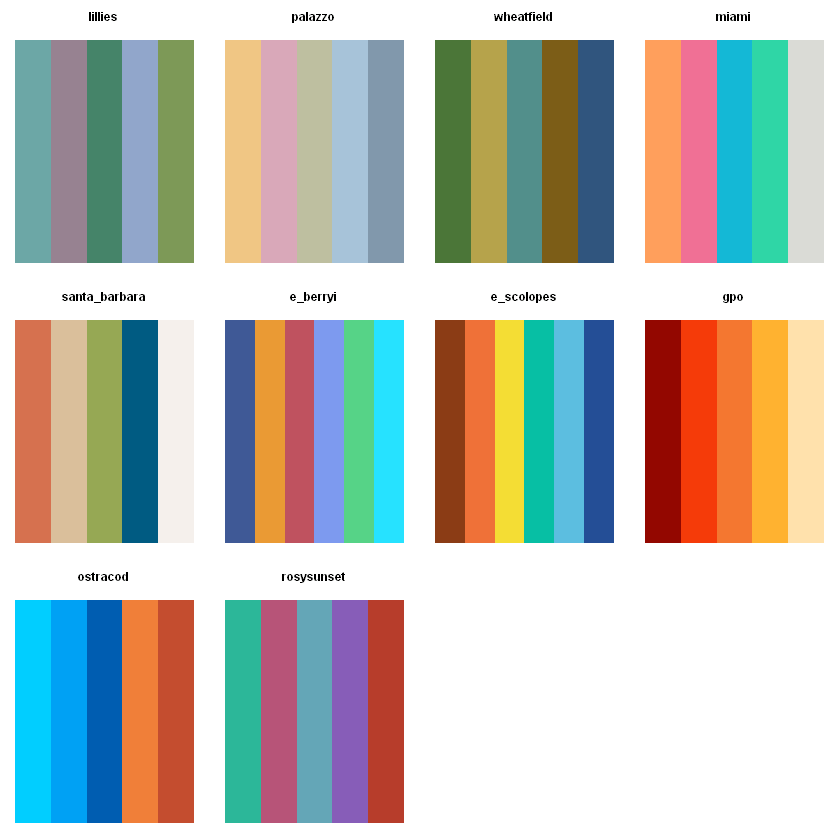

In [7]:
palettes_show(names = palette_names)

## Color‑vision deficiency simulations

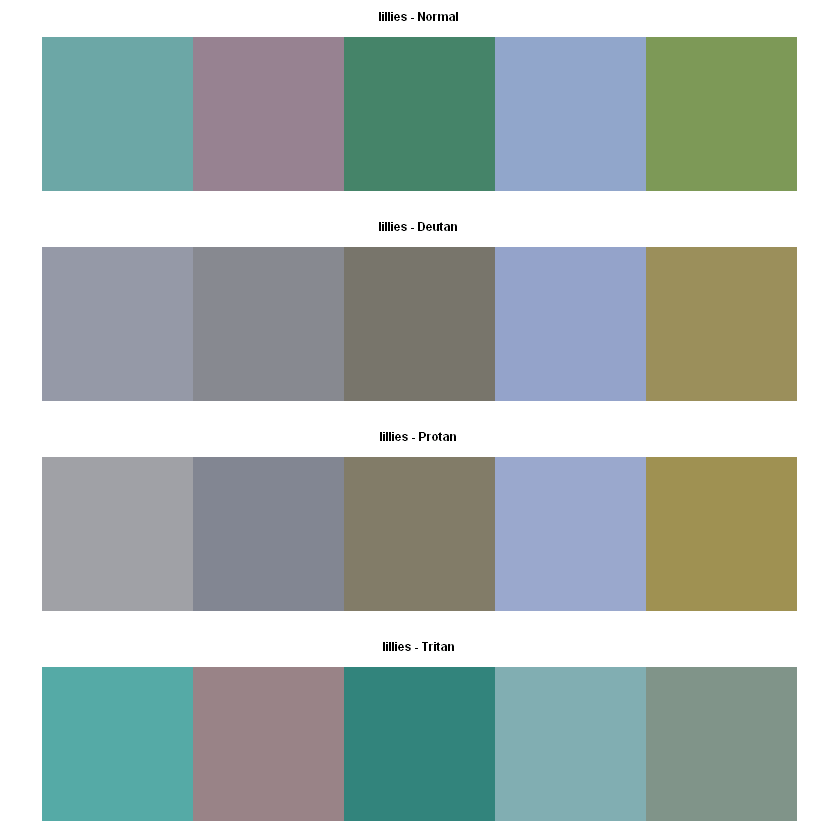

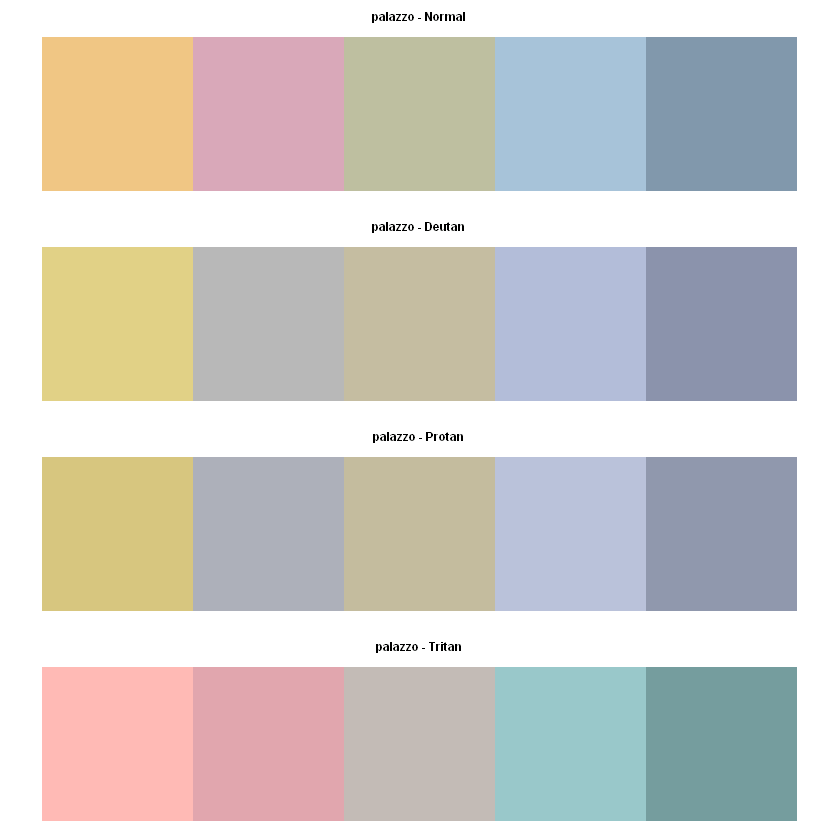

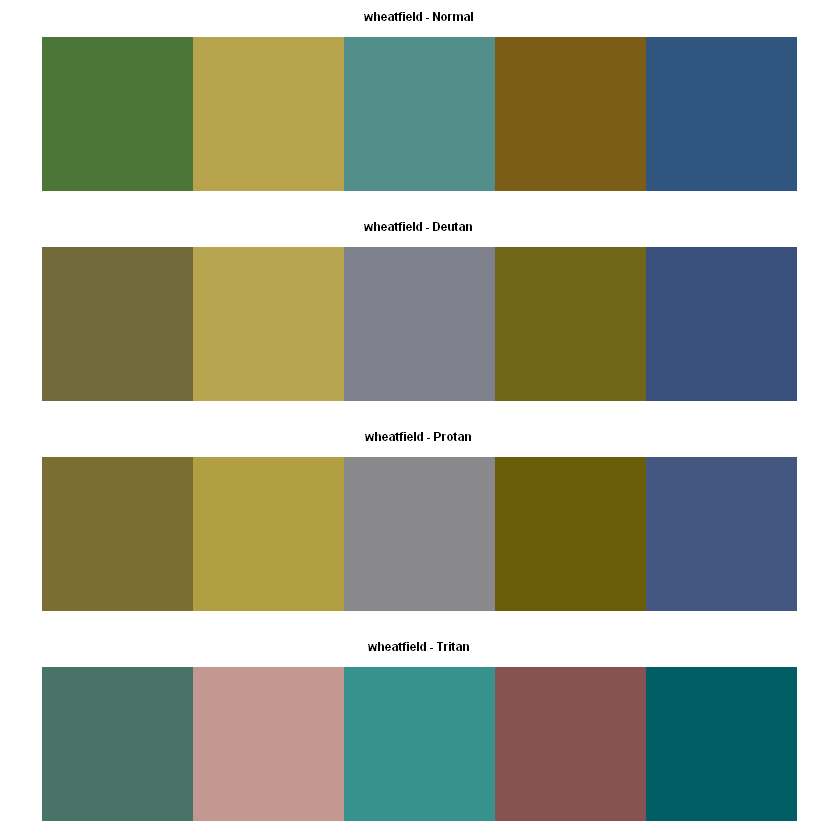

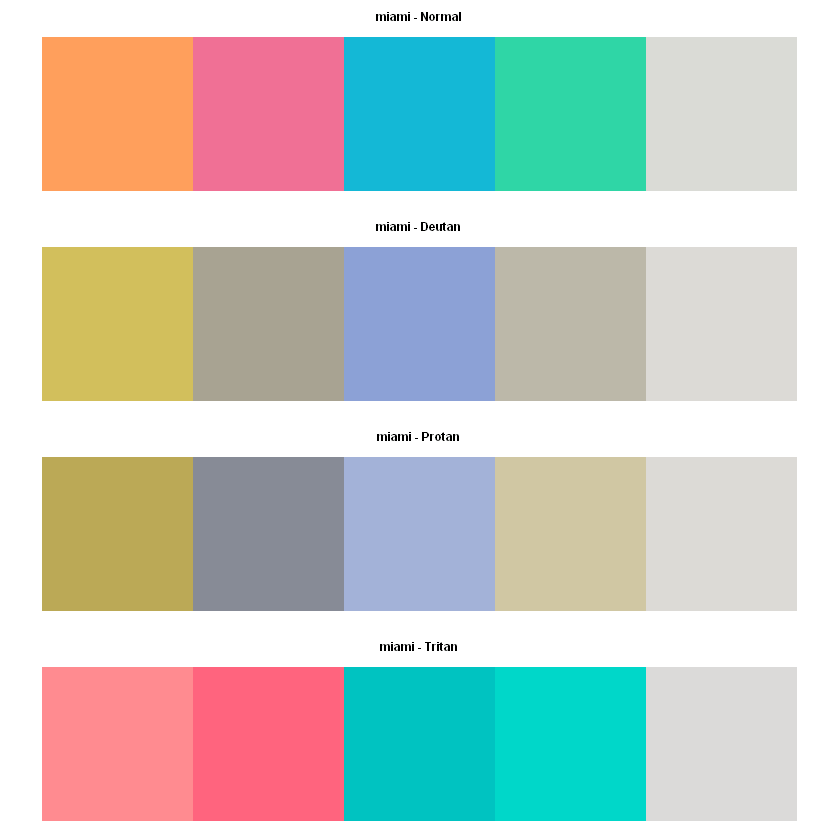

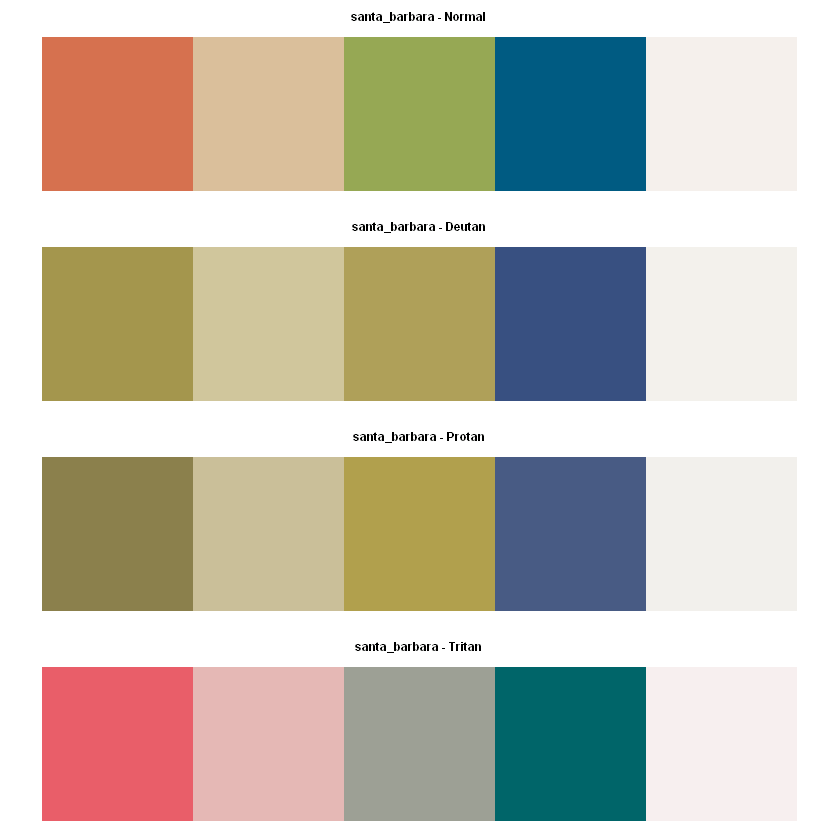

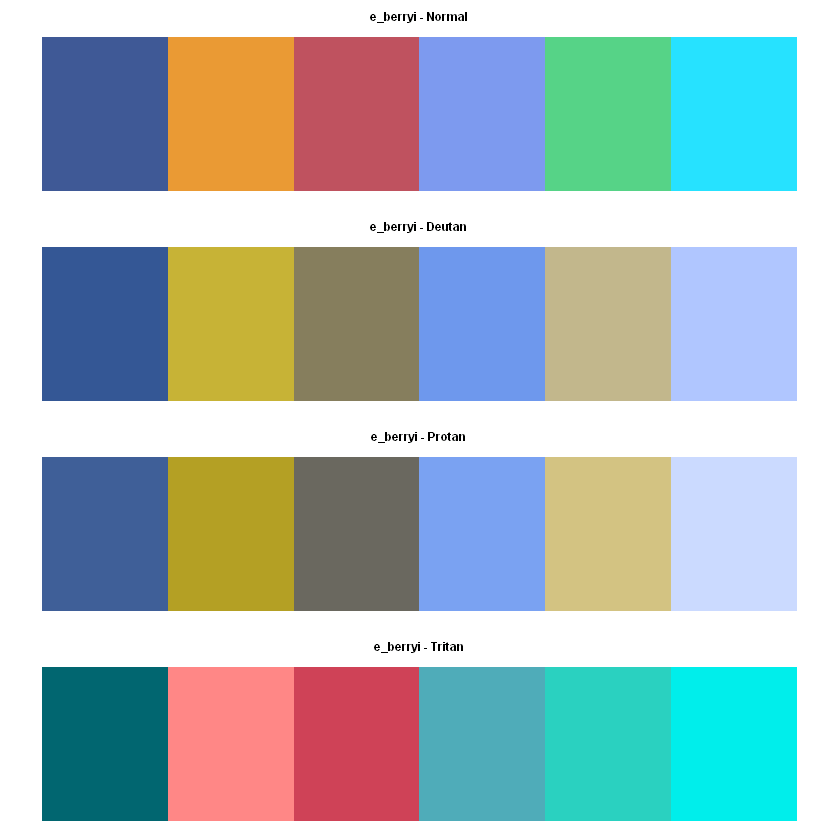

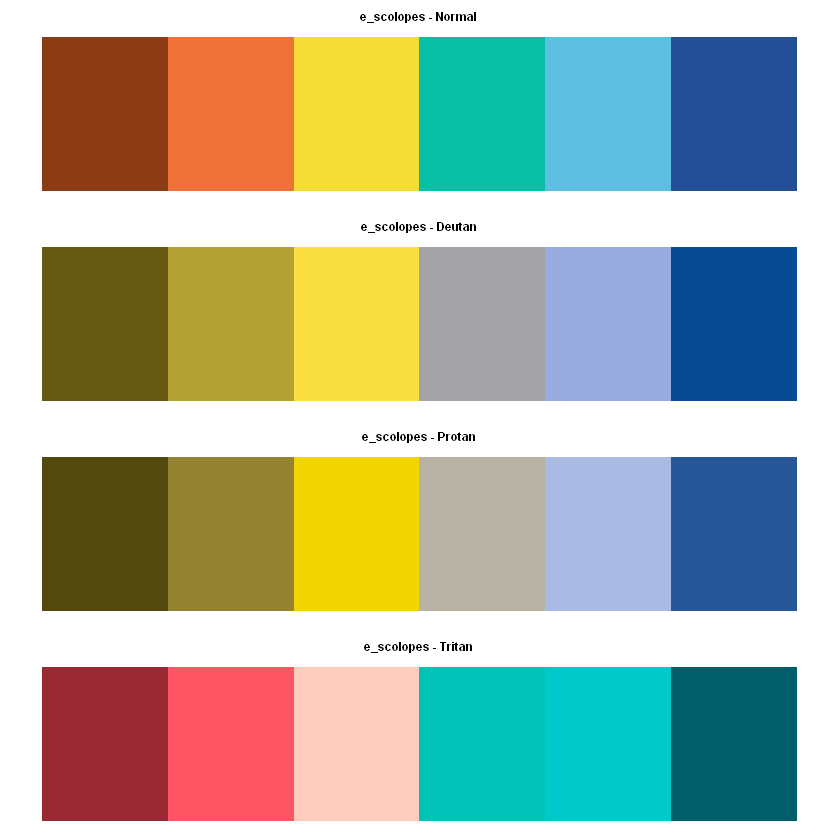

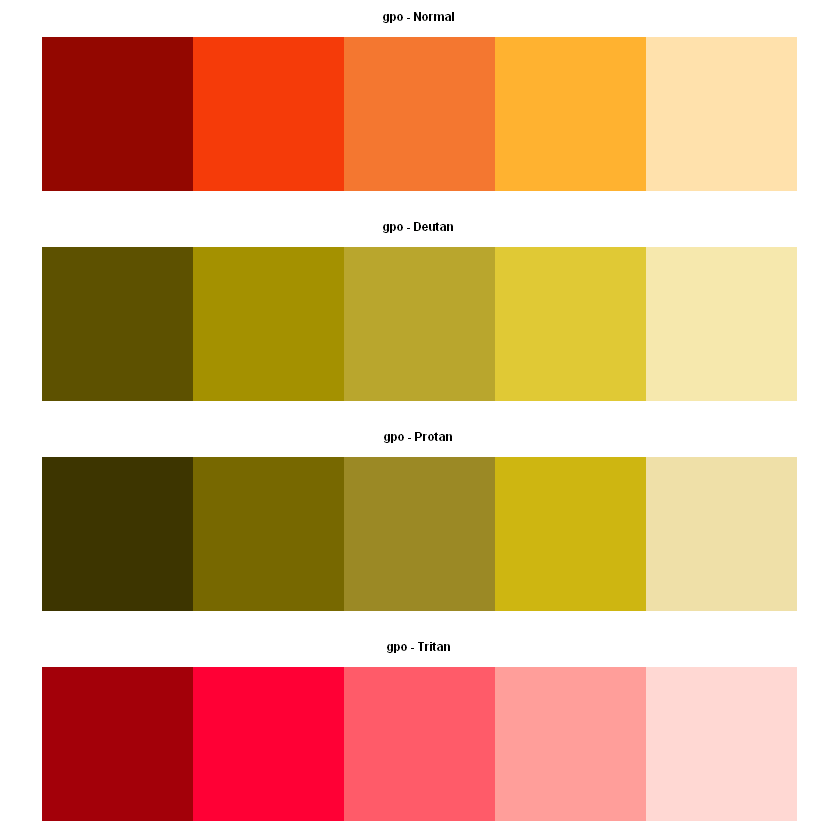

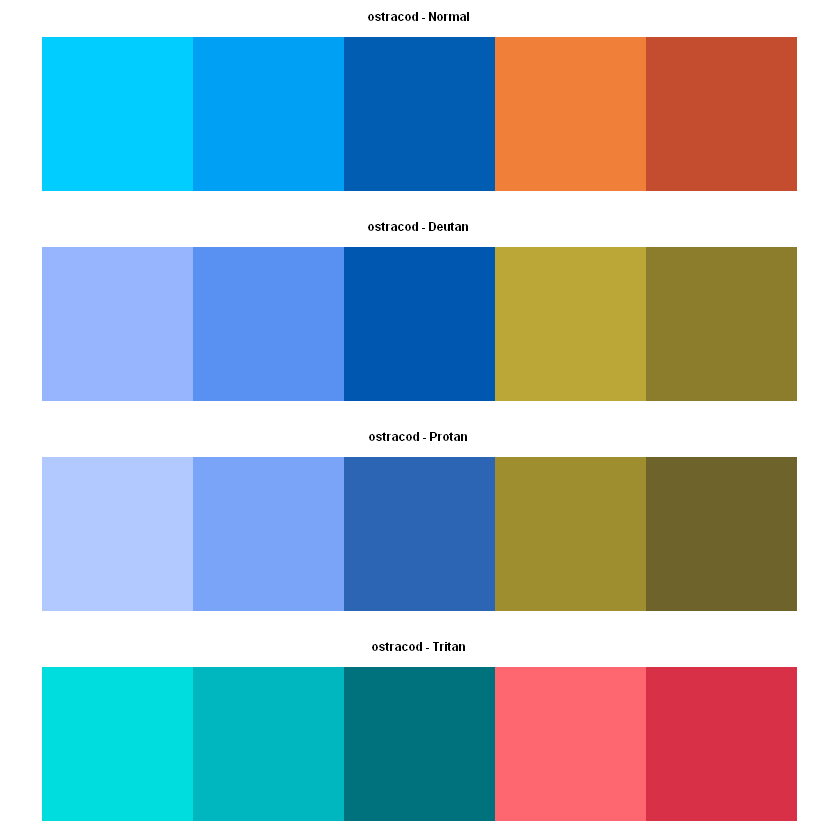

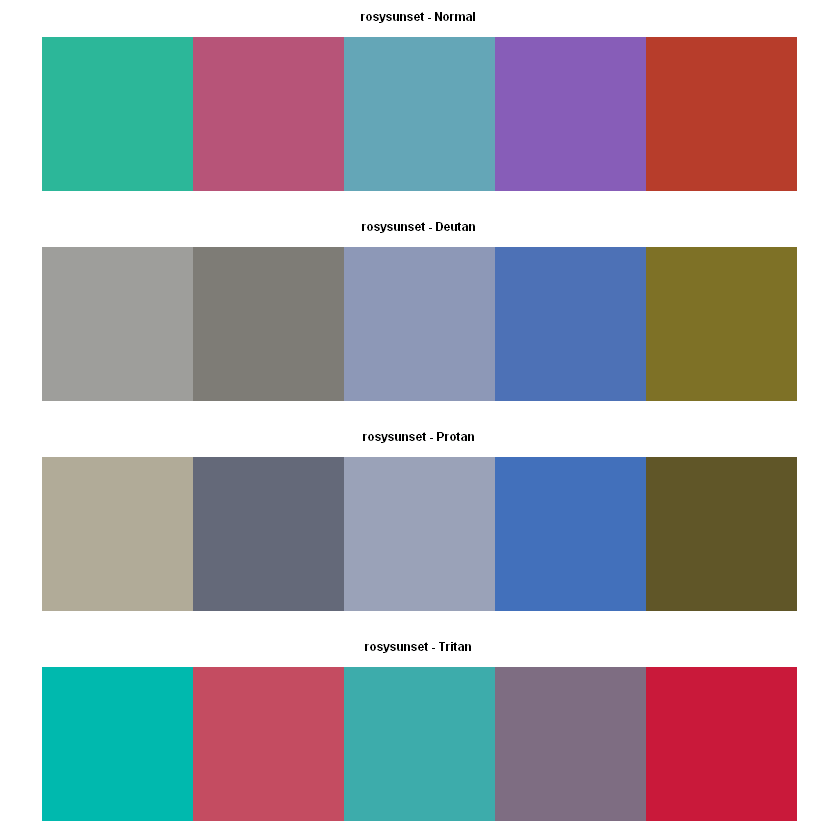

In [5]:
plot_colors <- function(cols, main = NULL) {
  par(mar = c(0.8, 0.8, 2, 0.8))
  plot.new()
  x <- seq(0, 1, length.out = length(cols) + 1)
  for (i in seq_along(cols)) {
    rect(x[i], 0, x[i + 1], 1, col = cols[i], border = NA)
  }
  if (!is.null(main)) title(main, cex.main = 0.9)
}

simulate_cvd_safe <- function(cols, cvd_type) {
  normalize_cvd_output <- function(x) {
    if (is.character(x)) return(x)
    if (is.matrix(x)) return(rgb(x[, 1], x[, 2], x[, 3]))
    if (inherits(x, c("RGB", "sRGB", "polarLUV", "polarLAB"))) return(colorspace::hex(x))
    return(x)
  }

  try_call <- function(expr) {
    out <- try(expr, silent = TRUE)
    if (!inherits(out, "try-error")) return(normalize_cvd_output(out))
    NULL
  }

  fmls <- names(formals(colorspace::simulate_cvd))

  # Try with hex colors first
  if ("type" %in% fmls) {
    res <- try_call(colorspace::simulate_cvd(cols, type = cvd_type))
    if (!is.null(res)) return(res)
  }
  if ("cvd" %in% fmls) {
    res <- try_call(colorspace::simulate_cvd(cols, cvd = cvd_type))
    if (!is.null(res)) return(res)
  }
  res <- try_call(colorspace::simulate_cvd(cols, cvd_type))
  if (!is.null(res)) return(res)

  # Fallback: convert to numeric RGB matrix (0-1)
  rgb_mat <- t(col2rgb(cols)) / 255
  if ("type" %in% fmls) {
    res <- try_call(colorspace::simulate_cvd(rgb_mat, type = cvd_type))
    if (!is.null(res)) return(res)
  }
  if ("cvd" %in% fmls) {
    res <- try_call(colorspace::simulate_cvd(rgb_mat, cvd = cvd_type))
    if (!is.null(res)) return(res)
  }
  res <- try_call(colorspace::simulate_cvd(rgb_mat, cvd_type))
  if (!is.null(res)) return(res)

  # Additional fallback for colorspace versions exposing per-type helpers
  cvd_fun <- switch(
    cvd_type,
    deutan = get0("deutan", asNamespace("colorspace"), inherits = FALSE),
    protan = get0("protan", asNamespace("colorspace"), inherits = FALSE),
    tritan = get0("tritan", asNamespace("colorspace"), inherits = FALSE),
    NULL
  )
  if (is.function(cvd_fun)) {
    res <- try_call(cvd_fun(cols))
    if (!is.null(res)) return(res)
    res <- try_call(cvd_fun(rgb_mat))
    if (!is.null(res)) return(res)
  }

  stop("simulate_cvd failed for this colorspace version.")
}

preview_cvd <- function(palette, n = NULL, type = c("discrete", "continuous")) {
  type <- match.arg(type)
  cols <- get_palette(palette, n = n, type = type)
  validate_palette(cols)

  sims <- list(
    Normal = cols,
    Deutan = simulate_cvd_safe(cols, "deutan"),
    Protan = simulate_cvd_safe(cols, "protan"),
    Tritan = simulate_cvd_safe(cols, "tritan")
  )

  op <- par(no.readonly = TRUE)
  on.exit(par(op), add = TRUE)
  par(mfrow = c(length(sims), 1))
  for (nm in names(sims)) plot_colors(sims[[nm]], paste(palette, "-", nm))
}

# Preview all palettes with CVD simulation
for (pal in palette_names) {
  preview_cvd(pal)
}

## Discrete data example

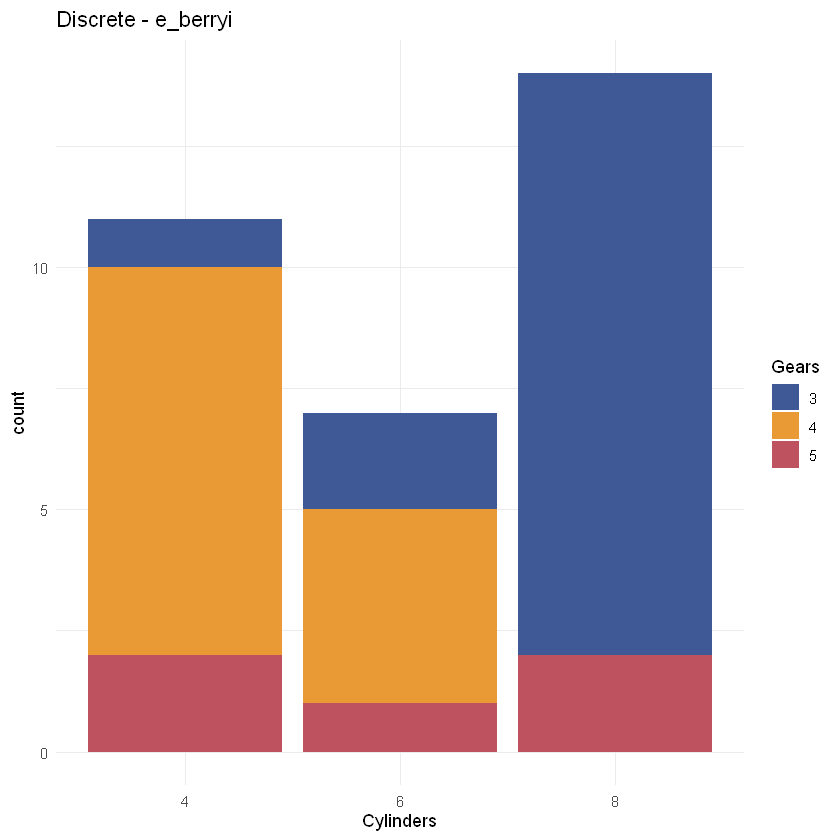

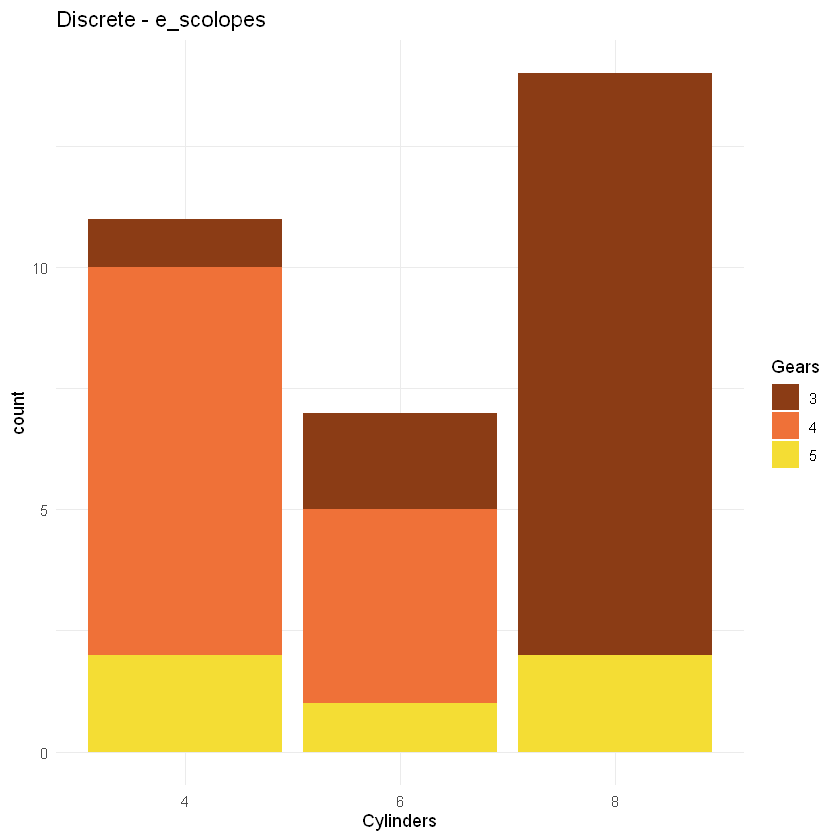

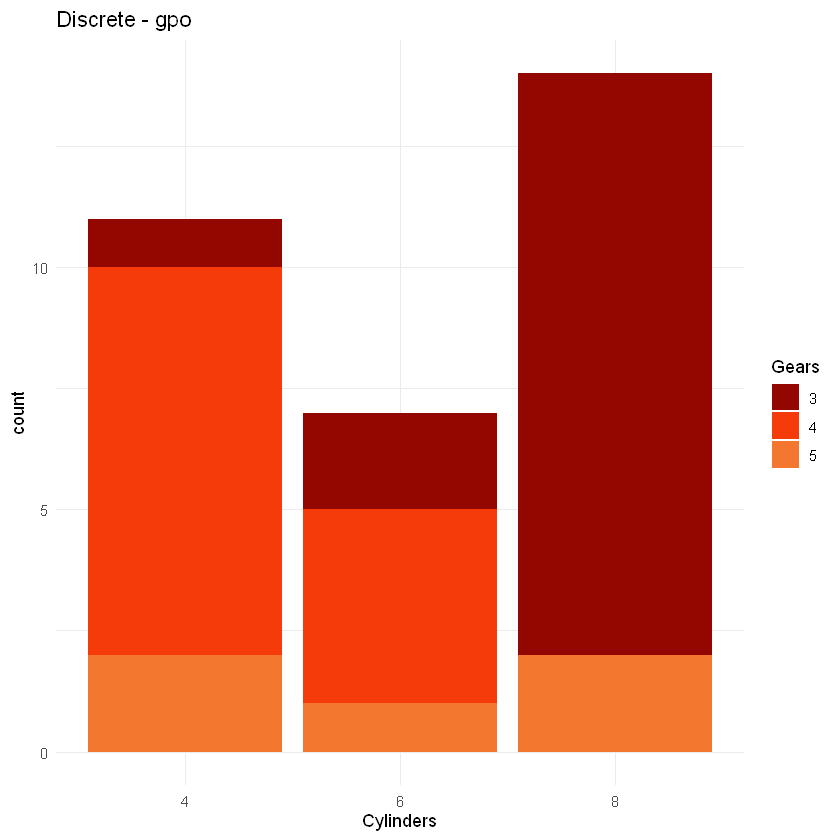

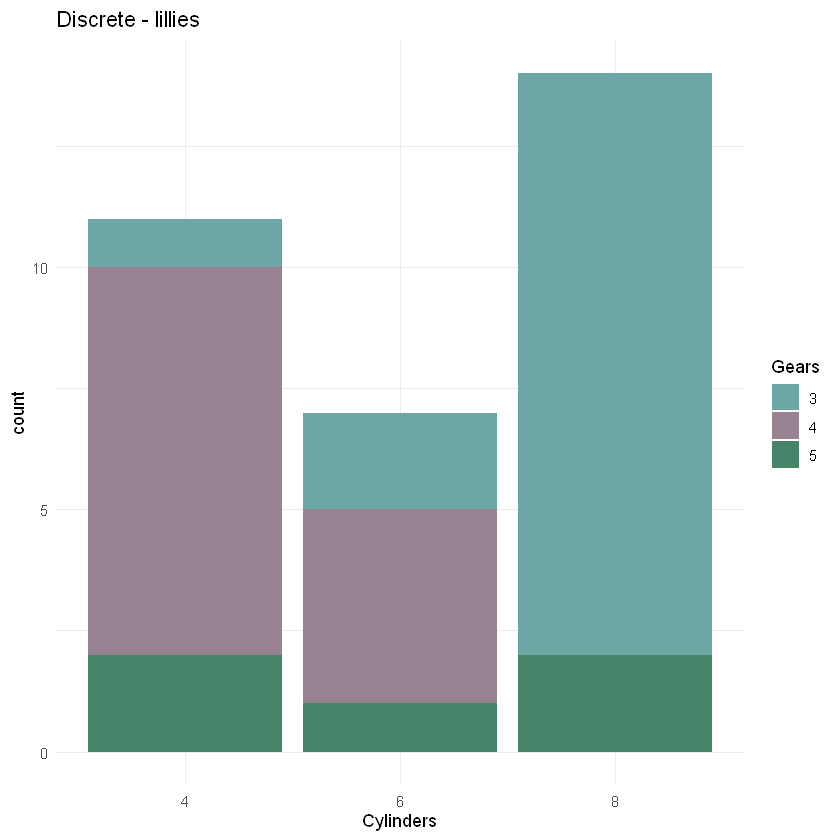

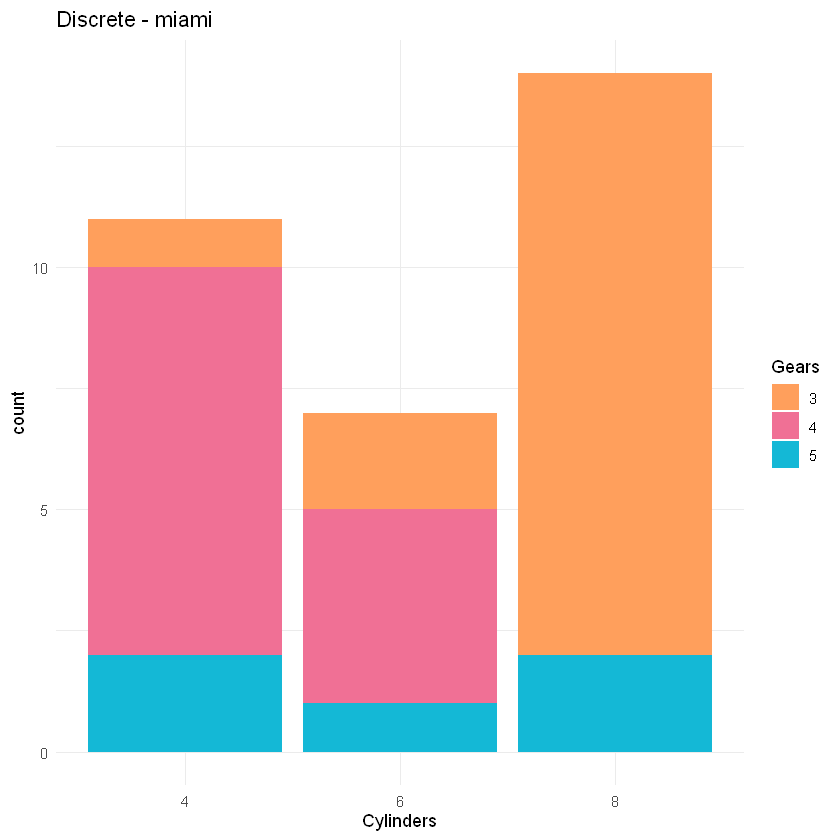

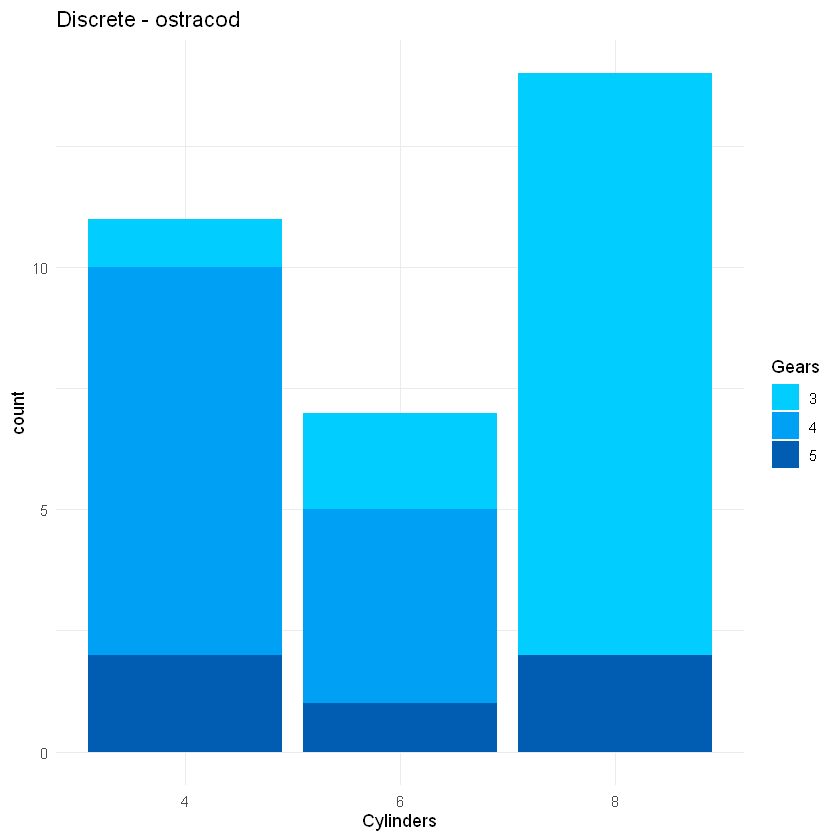

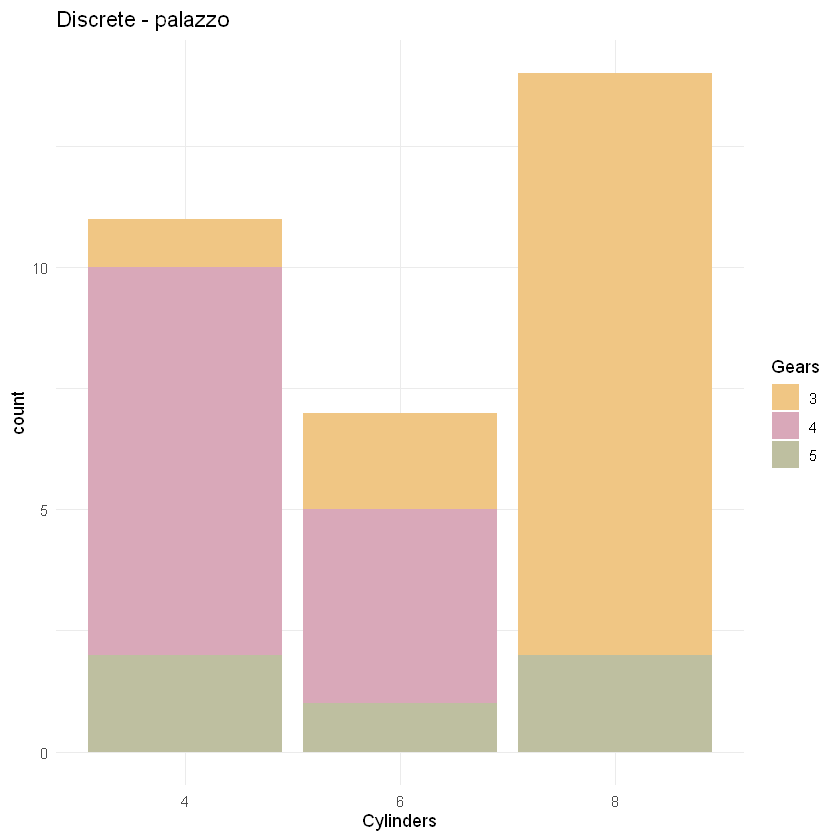

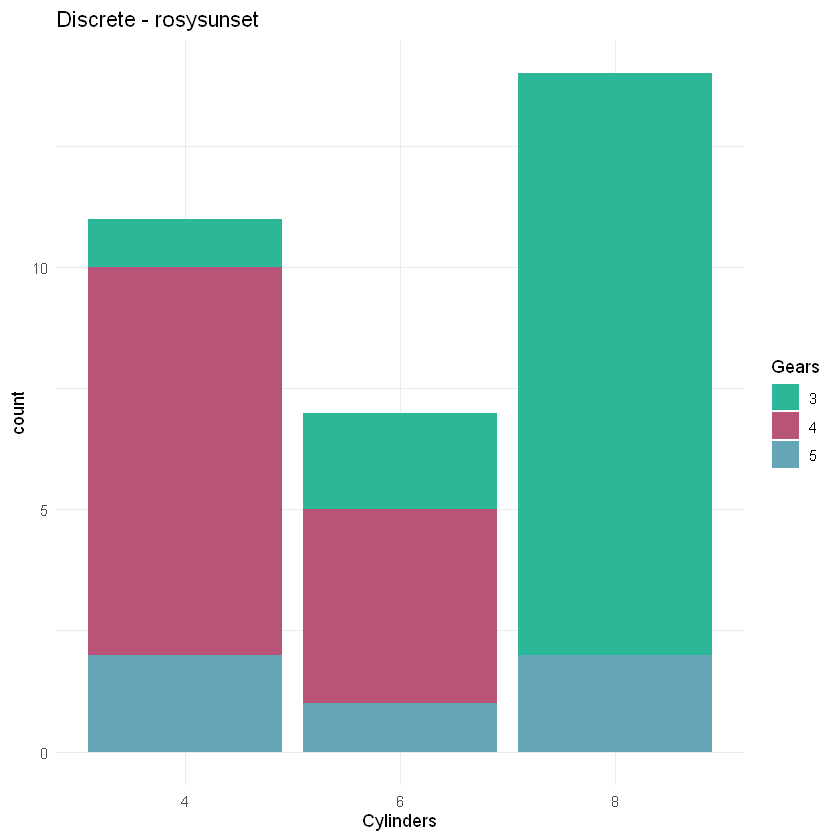

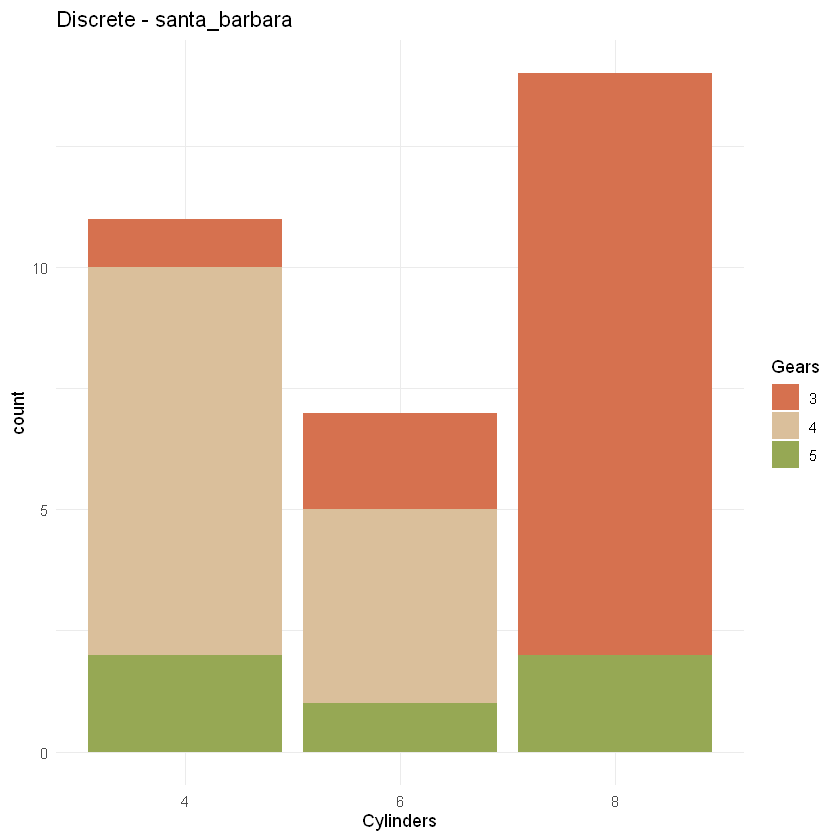

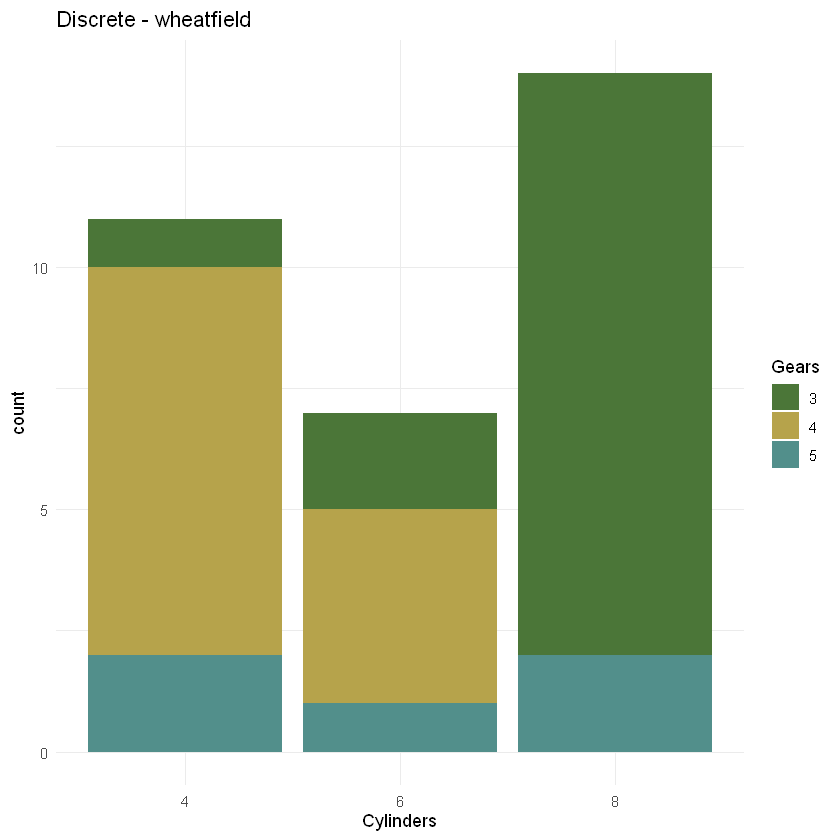

In [21]:
for (pal in palette_names) {
  p <- ggplot(mtcars, aes(x = factor(cyl), fill = factor(gear))) +
    geom_bar() +
    scale_fill_palettes(pal) +
    labs(title = paste("Discrete -", pal), x = "Cylinders", fill = "Gears") +
    theme_minimal()
  print(p)
}

## Continuous data example

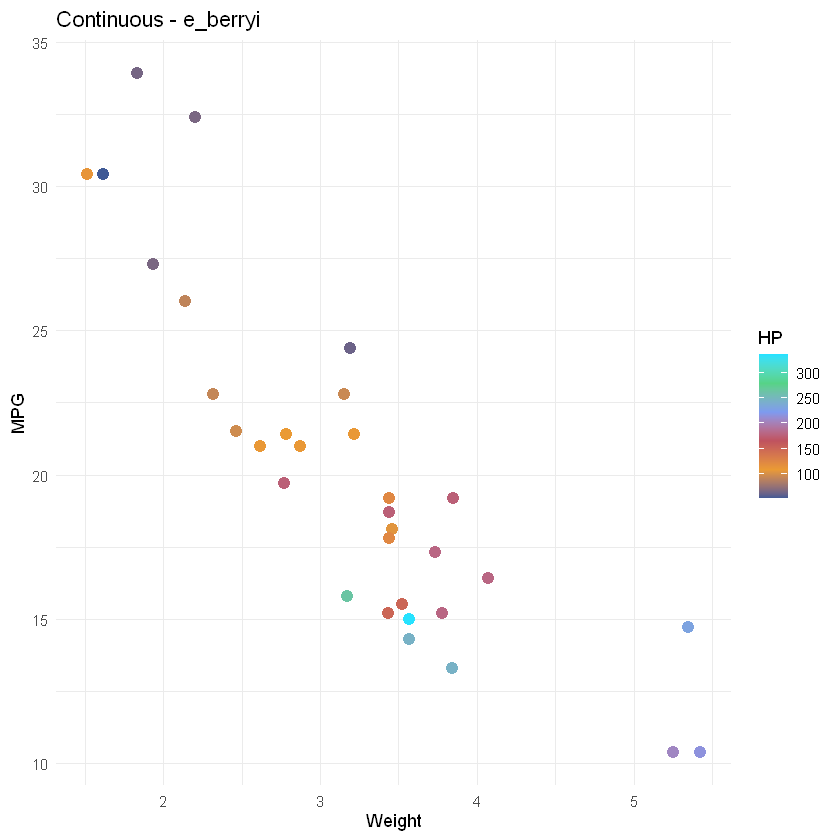

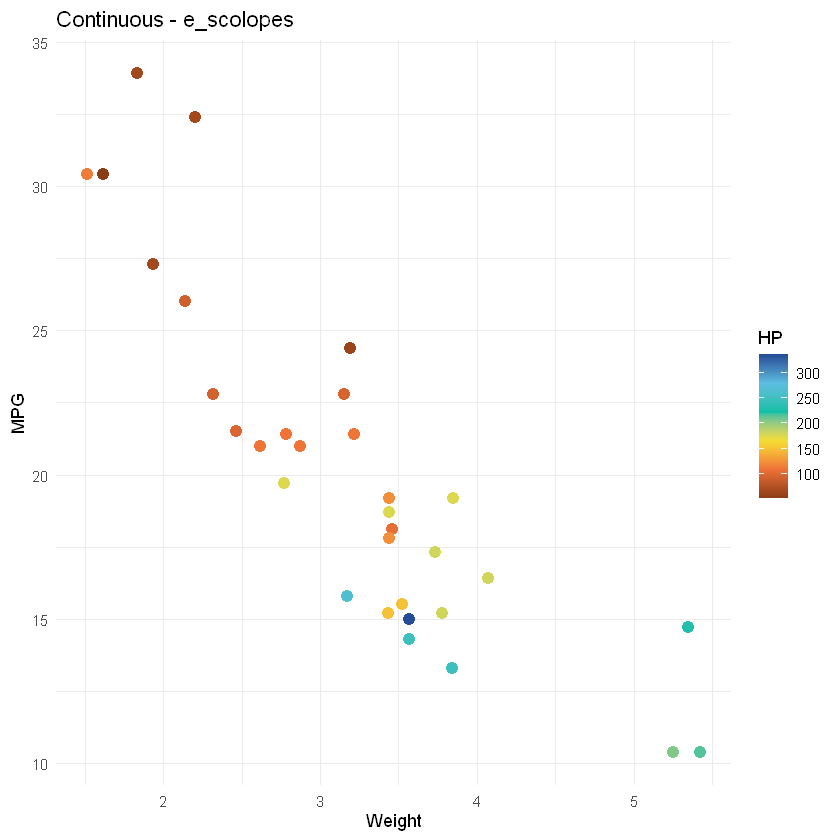

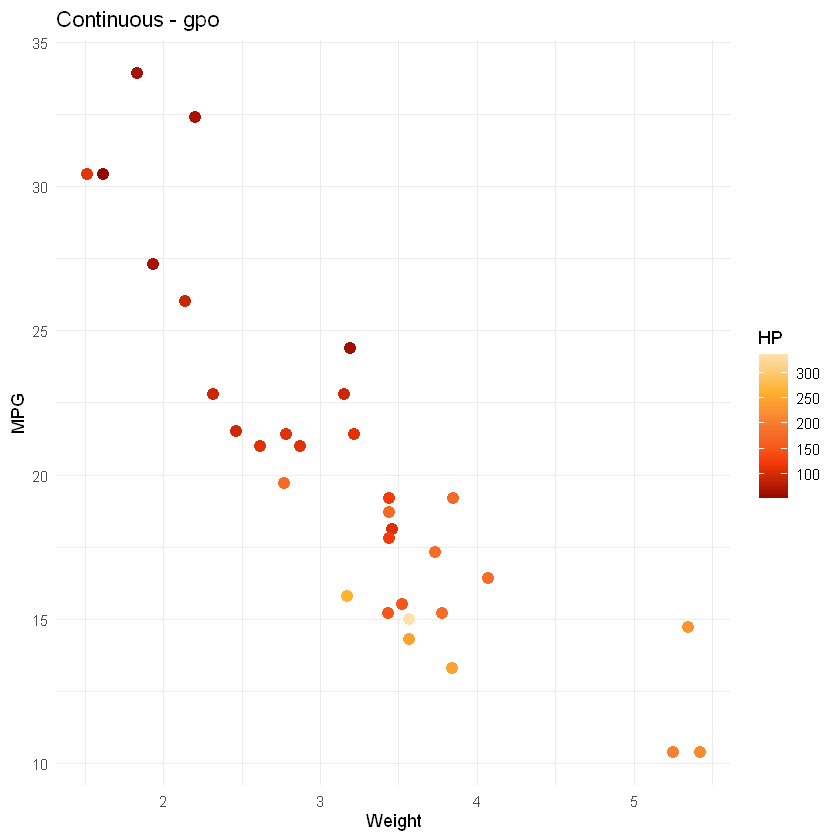

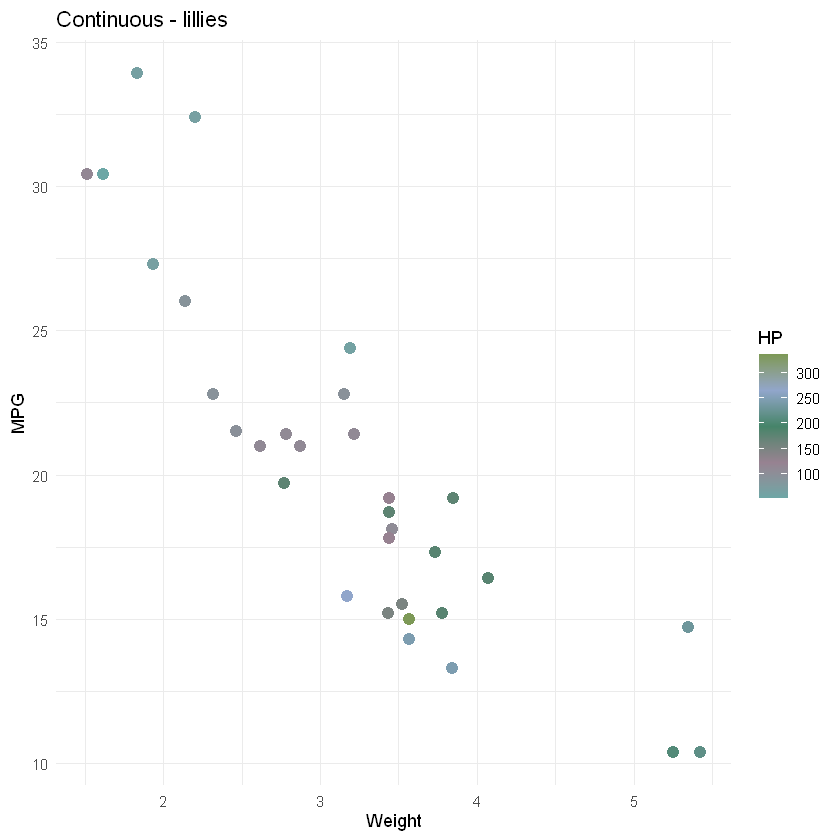

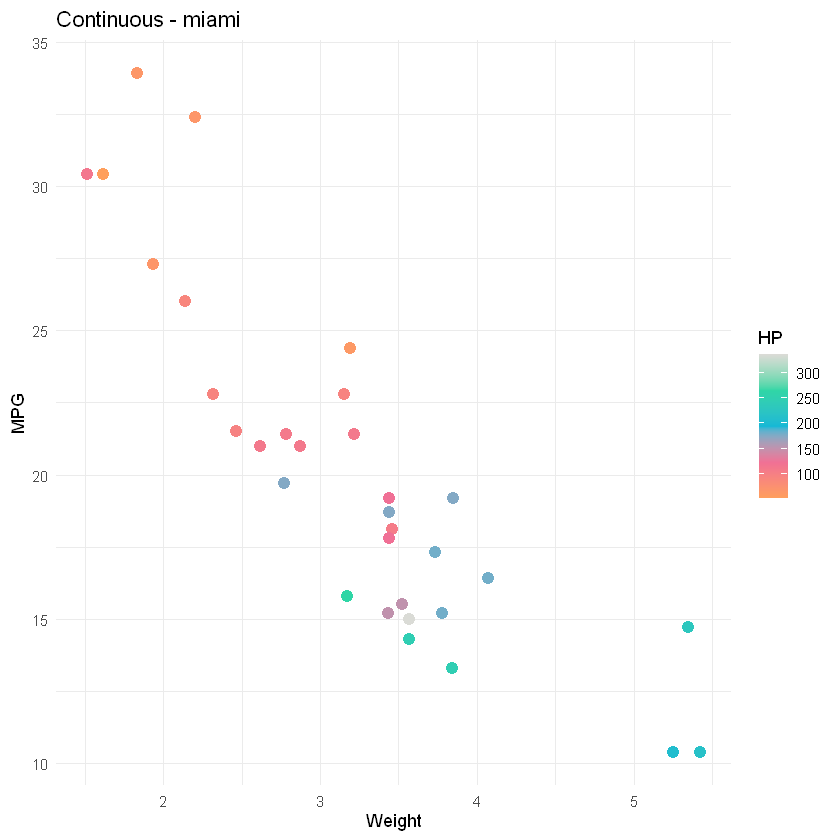

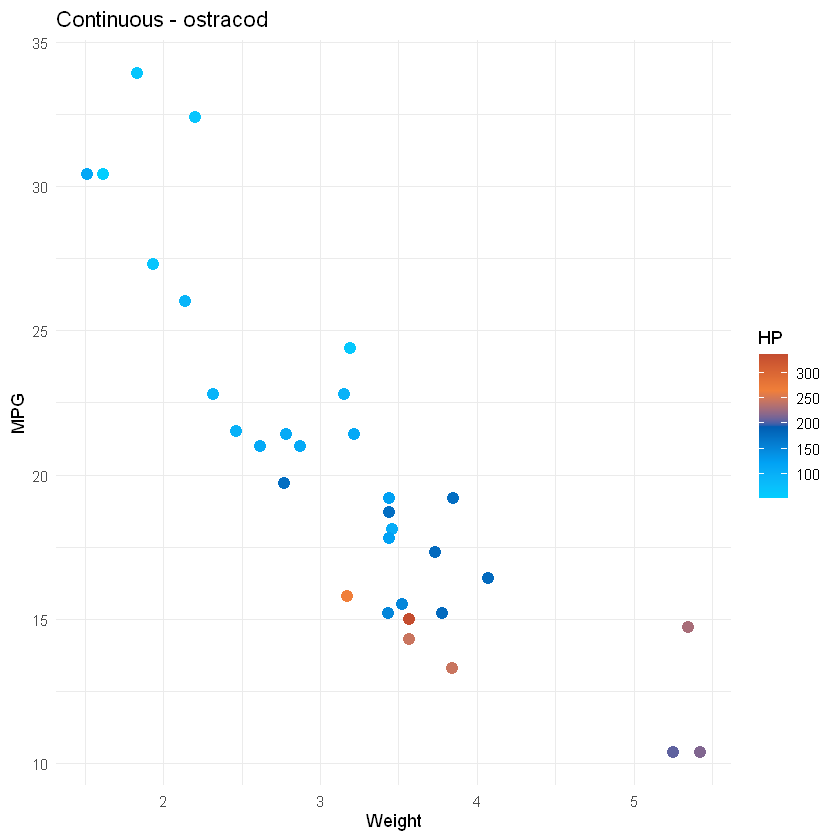

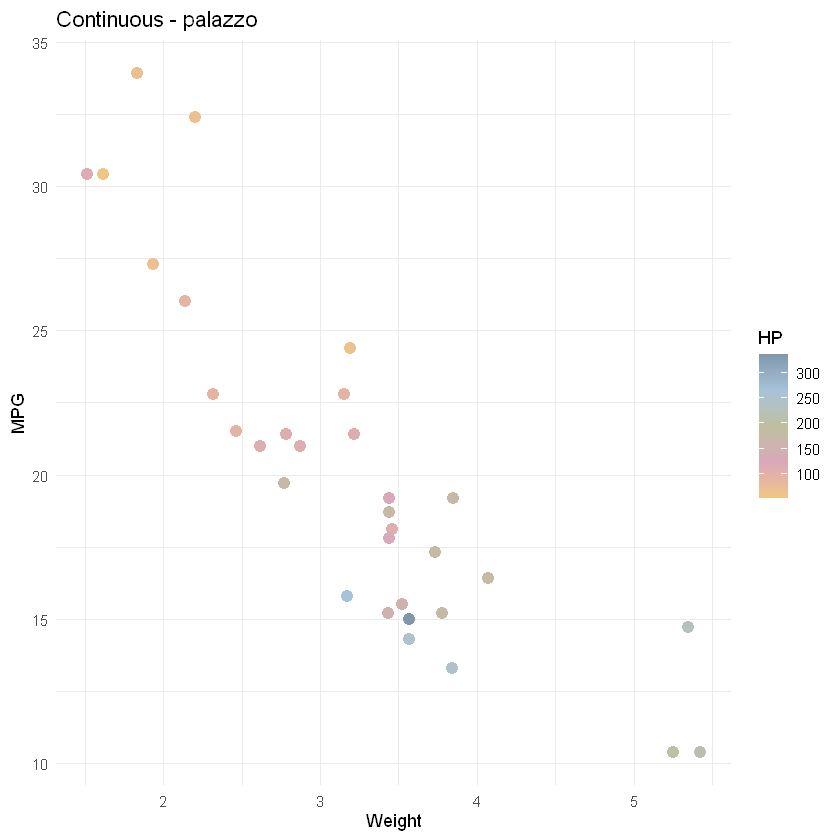

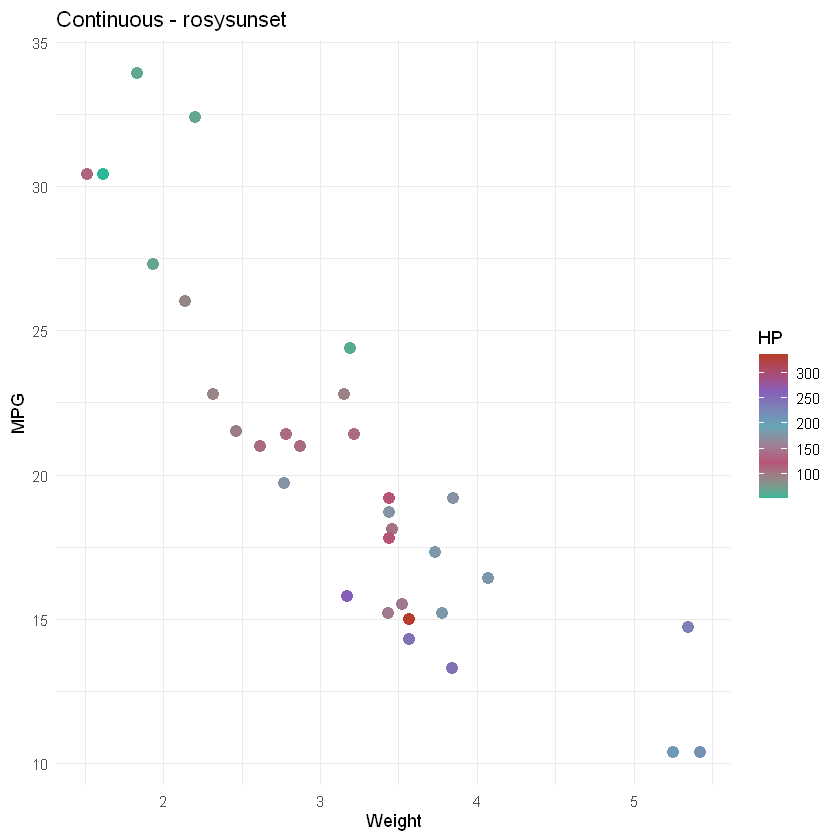

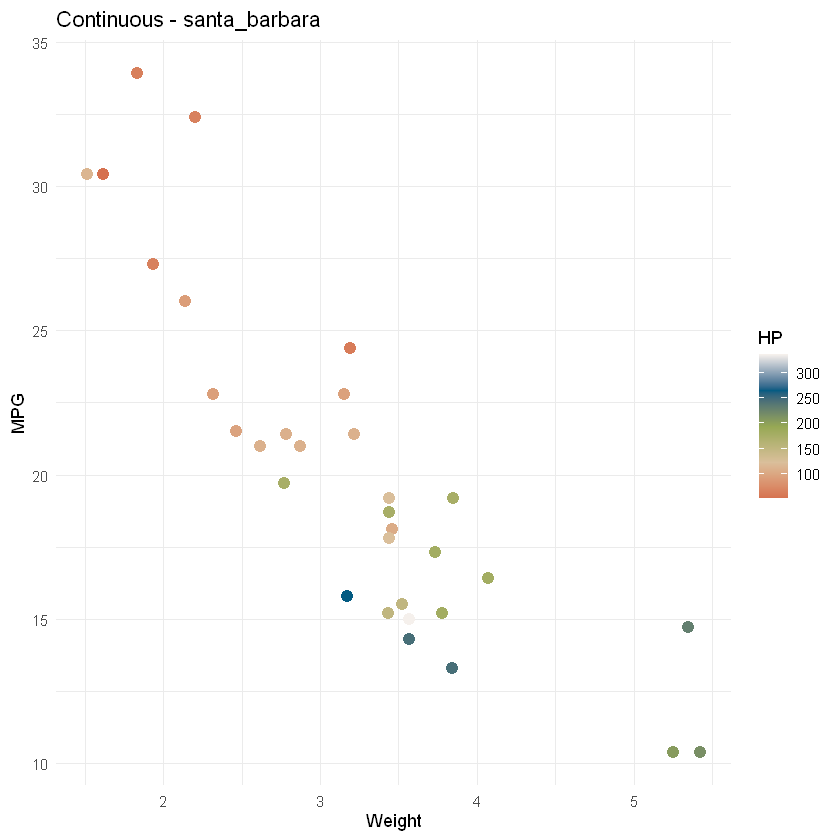

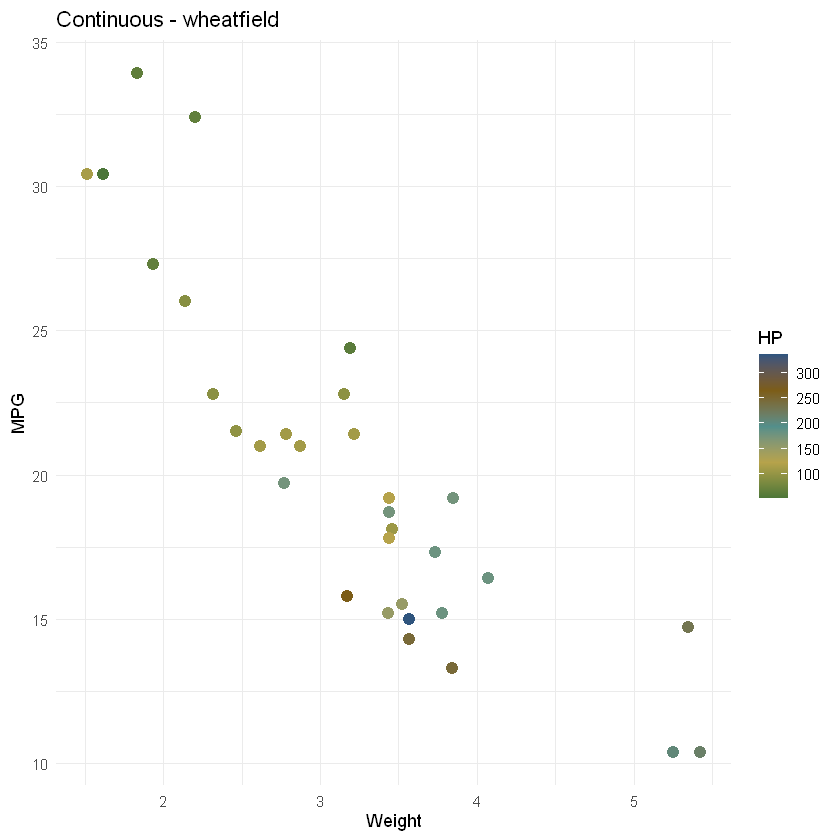

In [22]:
for (pal in palette_names) {
  p <- ggplot(mtcars, aes(x = wt, y = mpg, color = hp)) +
    geom_point(size = 3) +
    scale_color_palettes_continuous(pal) +
    labs(title = paste("Continuous -", pal), x = "Weight", y = "MPG", color = "HP") +
    theme_minimal()
  print(p)
}

## Map example

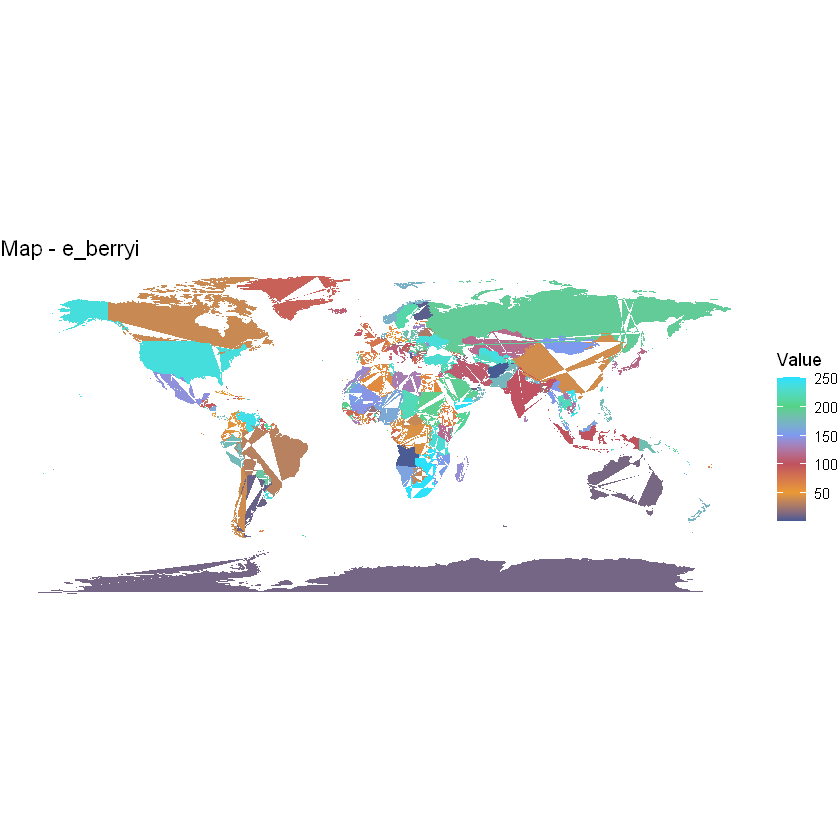

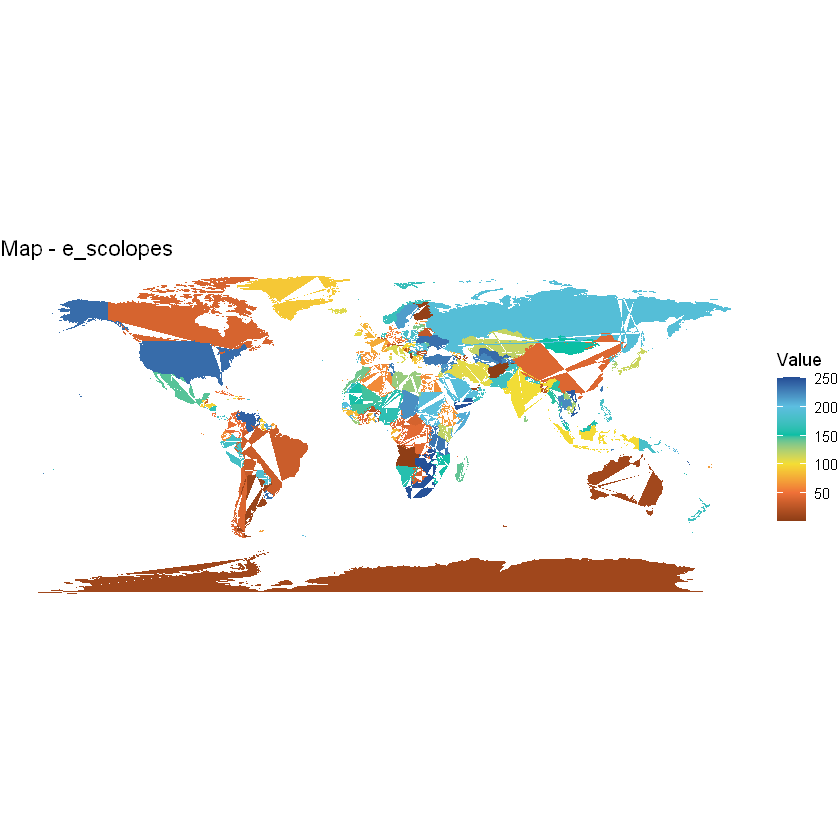

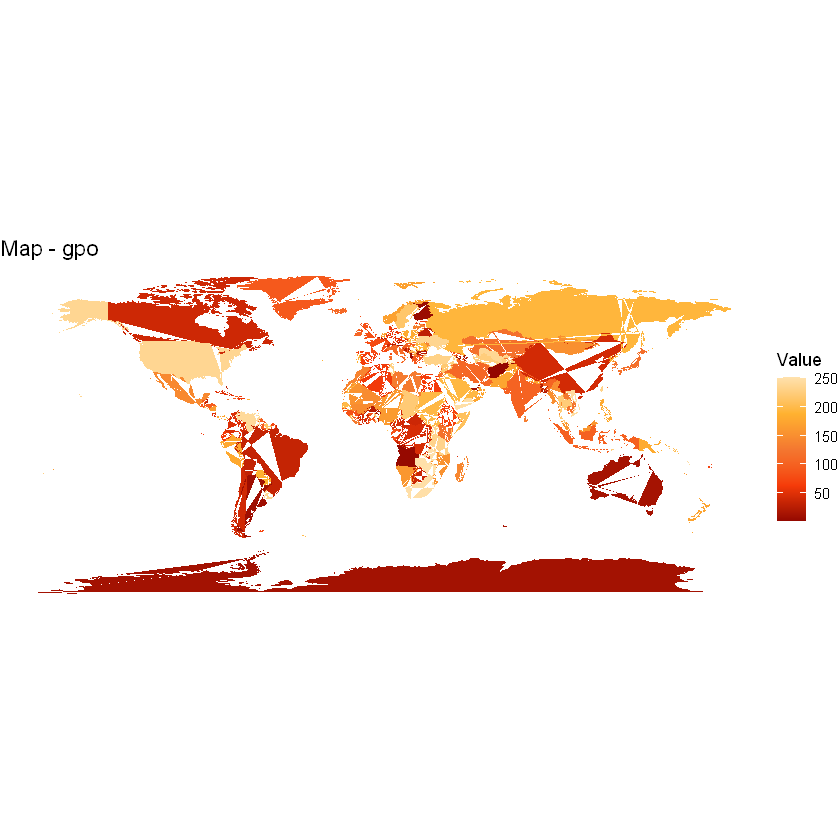

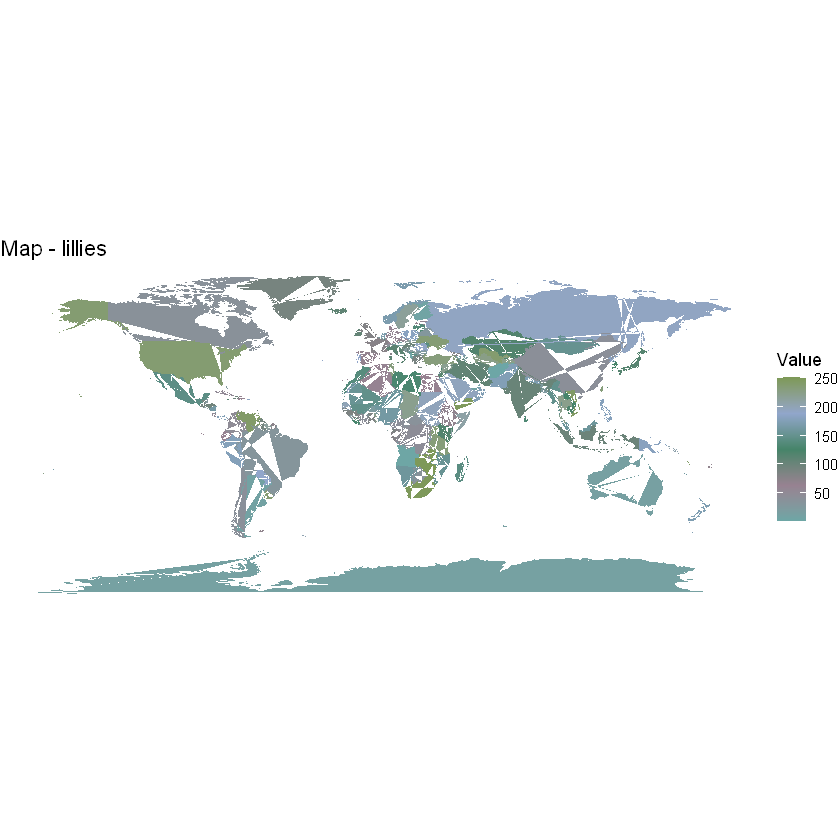

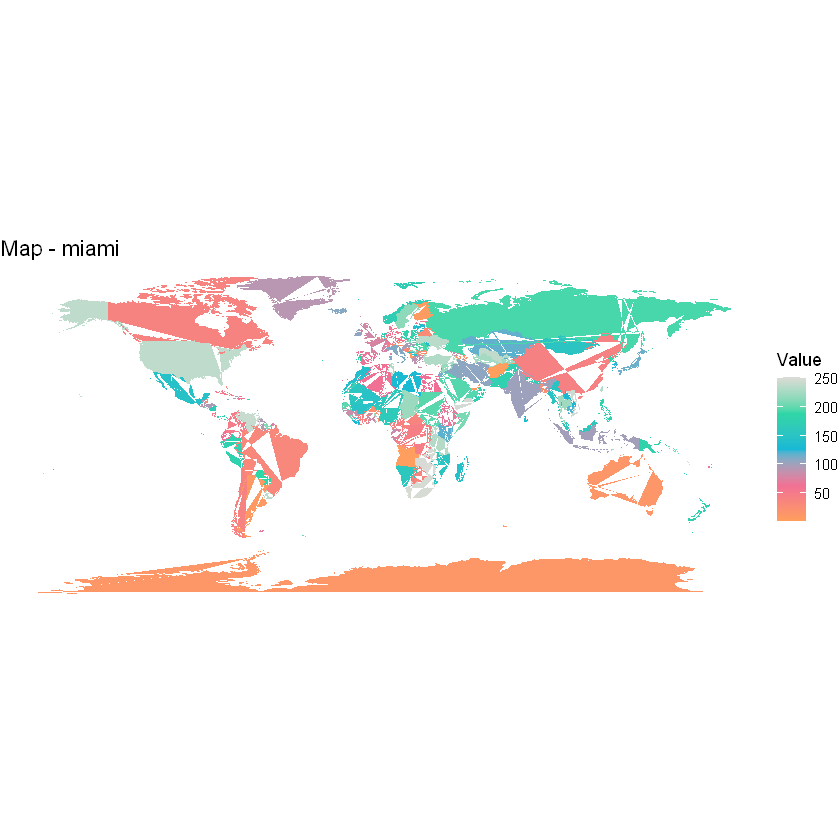

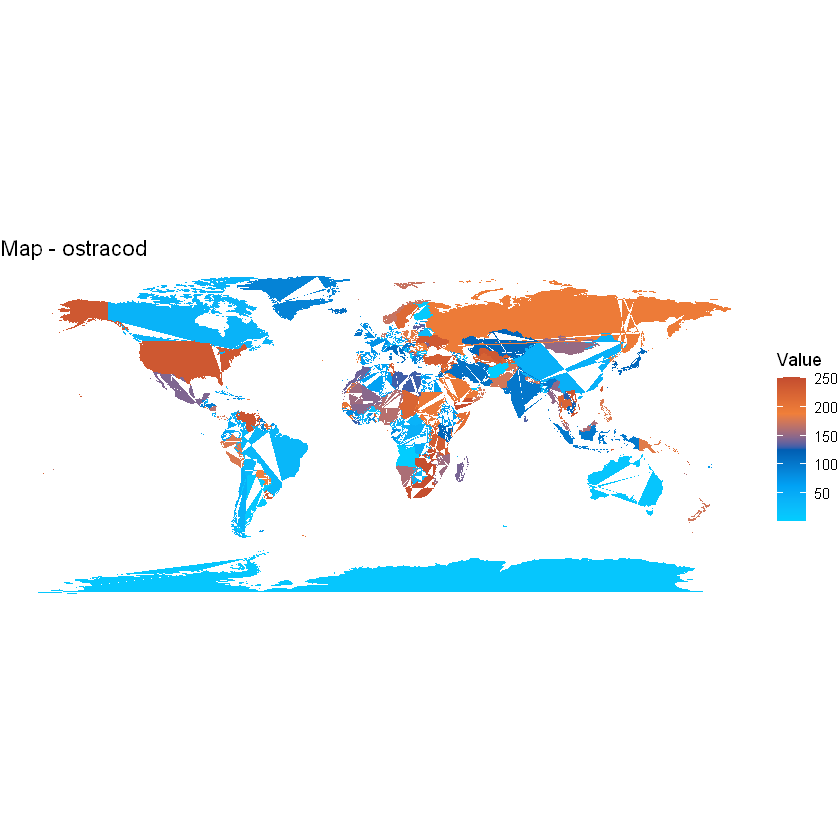

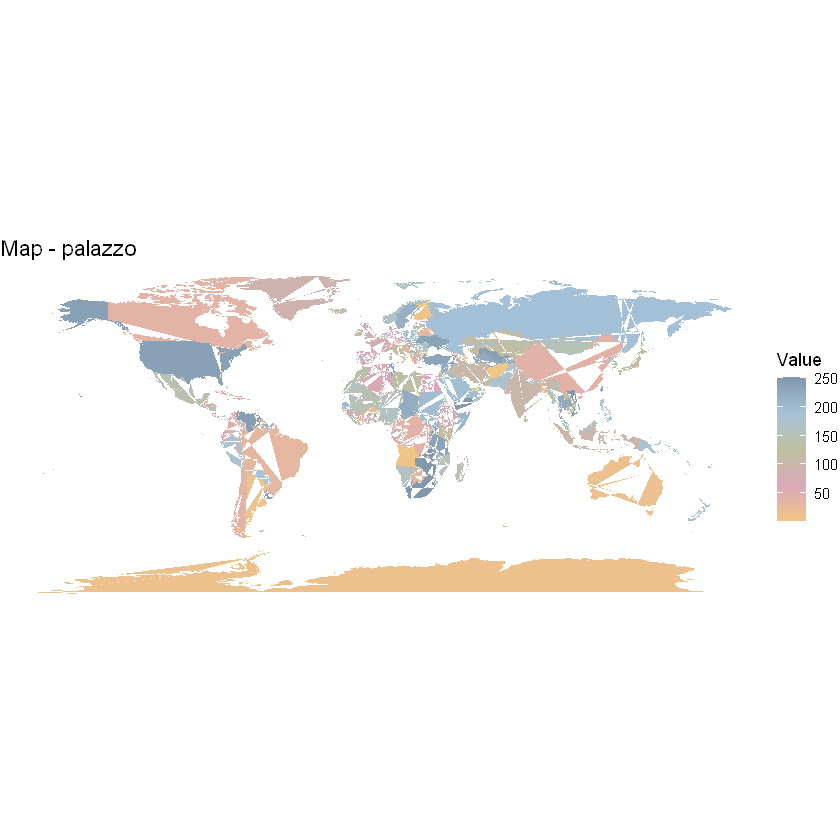

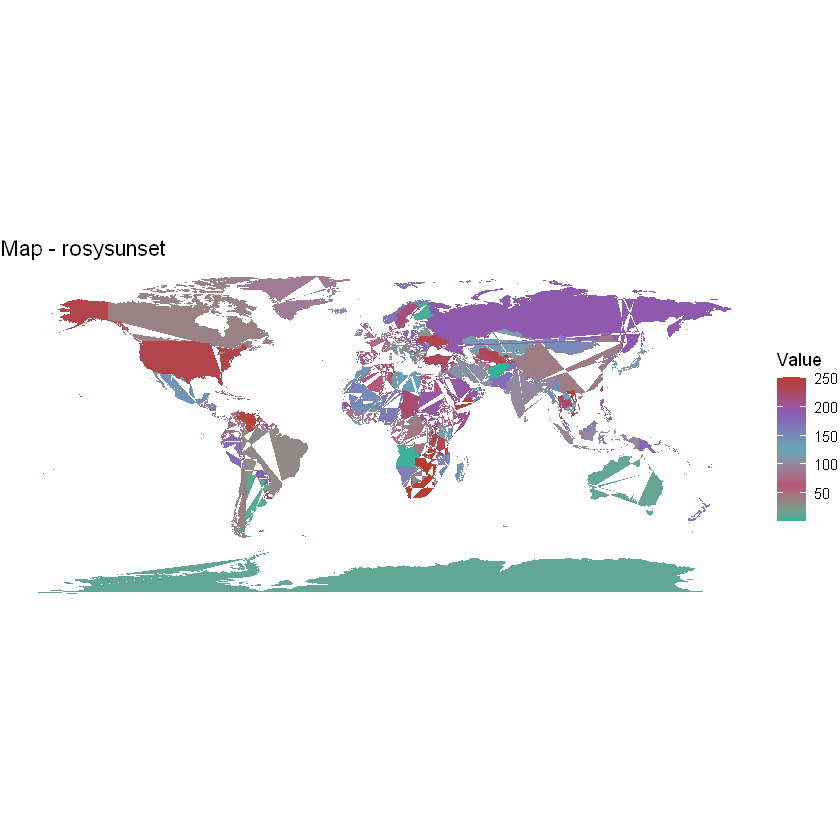

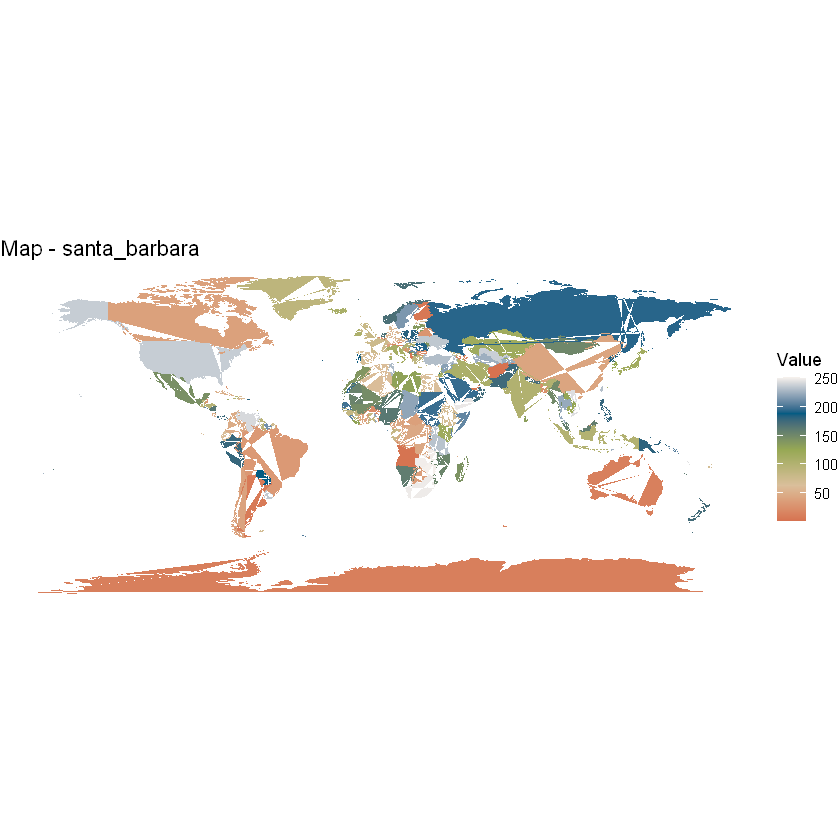

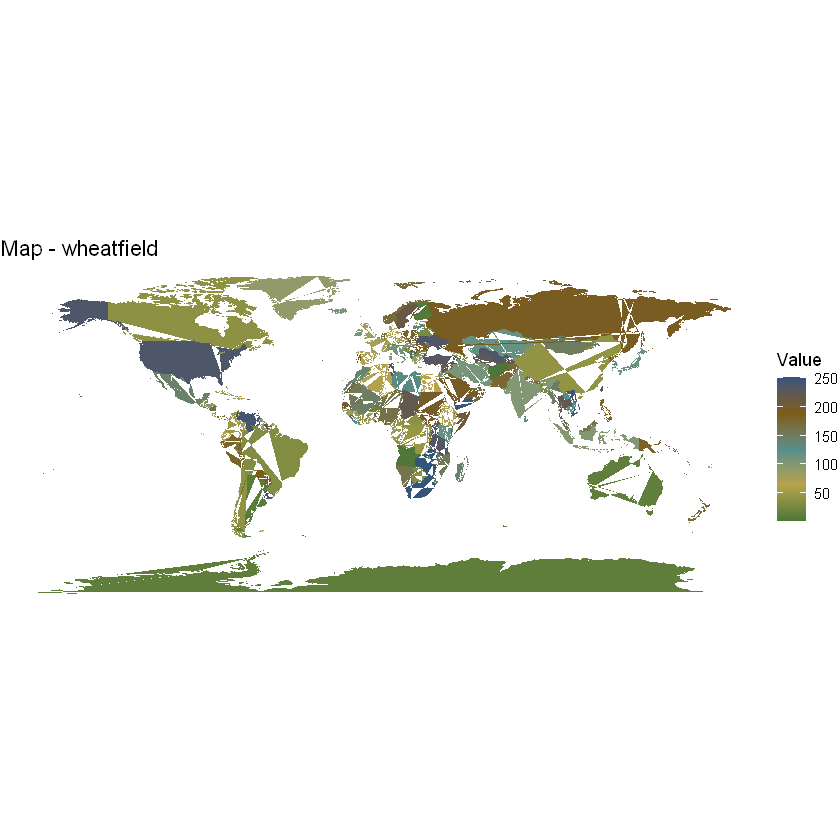

In [23]:
world <- ggplot2::map_data("world")
regions <- unique(world$region)
values <- data.frame(region = regions, value = seq_along(regions))
world2 <- merge(world, values, by = "region", all.x = TRUE)

for (pal in palette_names) {
  p <- ggplot(world2, aes(long, lat, group = group, fill = value)) +
    geom_polygon(color = NA) +
    coord_quickmap() +
    scale_fill_palettes_continuous(pal) +
    theme_void() +
    labs(title = paste("Map -", pal), fill = "Value")
  print(p)
}